Simulated Annealing Plots

In [4]:
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Parameters
results_path = 'data/simulated_annealing/summary_2026-04-20_01-38-38.npy'
brute_force_data_directory = './data/brute_force/test/test' # use same as in cl_optimizer_experiments

In [6]:
import numpy as np

result_tensor = np.load(results_path)

In [7]:
result_tensor.shape # should be a 6-tuple: (n_problem_sizes, n_load_factors, n_instances_per_problem_size, n_runs_per_instance, n_temp_iter_steps, 2)

(19, 10, 10, 2, 8, 2)

In [8]:
loss_tensor = result_tensor[..., 1]
temp_iterations = result_tensor[0, 0, 0, 0, :, 0]

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import re

extract_candidate_dimension = lambda p: np.log2(int(re.search(string=str(p.name), pattern=r'_(\d*)_candidates').group(1)))
extract_load_factor = lambda p: float(re.search(string=str(p.name), pattern=r'_(\d*\.\d*)_load_factor').group(1))

data_files = [p for p in Path(brute_force_data_directory).glob("*.csv") if p.is_file()]
candidate_dims = [(extract_candidate_dimension(p), extract_load_factor(p), p) for p in data_files]

df = pd.DataFrame(data=candidate_dims, columns=['dim', 'load factor', 'path'])
df = df.groupby(['dim', 'load factor'])['path'].agg(list).reset_index()

In [10]:
problem_sizes = df['dim'].unique()
load_factors = df['load factor'].unique()
brute_force_data_paths = np.array(df['path'].to_list(), dtype=object).reshape(len(problem_sizes), len(load_factors), -1)

In [11]:
import pandas as pd
import numpy as np
brute_force_data = np.vectorize(pd.read_csv)(brute_force_data_paths)
loss_spaces = [[np.array([d['loss'] for d in da]) for da in data] for data in brute_force_data] # needs to be list because is inhomogeneous

In [12]:
std_error_denominator = np.sqrt(result_tensor.shape[2])

In [13]:
# RAAR | Temperature Iterations
# RAAR | Problem Size N
from metrics import raar

avg_loss_runs = loss_tensor.mean(axis=3)
raars = np.array([[[[raar(avg, loss_spaces[i][j][k, :]) for avg in avg_loss]for k, avg_loss in enumerate(avg_loss_runs_per_load_factor)] for j, avg_loss_runs_per_load_factor in enumerate(avg_loss_runs_per_problem_size)] for i, avg_loss_runs_per_problem_size in enumerate(avg_loss_runs)])

mean_raars_per_load_factor = raars.mean(axis=(0, 2))
std_error_raars_per_load_factor = raars.std(axis=(0, 2)) / std_error_denominator

mean_raars = raars.mean(axis=(0, 2)).mean(axis=0) # average over load factor separately
std_error_raars = raars.std(axis=(0, 2)).mean(axis=0) / std_error_denominator

mean_raars_per_problem_size_and_load_factor = raars.mean(axis=(2, 3))
std_error_raars_per_problem_size_and_load_factor = raars.std(axis=(2, 3)) / std_error_denominator

mean_raars_per_problem_size = raars.mean(axis=(2, 3)).mean(axis=1) # average over load factor separately
std_error_raars_per_problem_size = raars.std(axis=(2, 3)).mean(axis=1) / std_error_denominator

In [14]:
# Find optimal candidates to calculate TTS*
min_losses = np.array([[s.min(axis=1) for s in spaces] for spaces in loss_spaces])
optimal_candidates_found = np.count_nonzero(loss_tensor ==  np.expand_dims(np.expand_dims(min_losses, axis=-1), axis=-1), axis=3)
p_star = optimal_candidates_found / loss_tensor.shape[-2] # probability of finding optimal candidate

In [15]:
result_tensor[..., 0, :, 0].shape

(19, 10, 10, 8)

In [16]:
p_star.shape

(19, 10, 10, 8)

In [17]:
# TTS* | Problem Size N
from metrics import min_tts
l_p = result_tensor[..., 0, :, 0] # use temperature iterations (but not per run)
tts_min = np.log(1000) * problem_sizes[:, np.newaxis, np.newaxis] * min_tts(p_star, l_p=l_p)

avg_min_tts_per_load_factor = tts_min.mean(axis=2)
std_error_min_tts_per_load_factor = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=2) / std_error_denominator

avg_min_tts = tts_min.mean(axis=-1).mean(axis=1) # average over load factor separately
std_error_min_tts = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=-1).mean(axis=1) / std_error_denominator

[0.1 0.3 0.7 1. ]


C:\Users\moritz\Desktop\UCP-PaperV2\plotting.py:138: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_linear, pcov_linear = curve_fit(f=linear_model, xdata=xs, ydata=log_mean_clipped, nan_policy='omit')
C:\Users\moritz\Desktop\UCP-PaperV2\plotting.py:139: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_log, pcov_log = curve_fit(
C:\Users\moritz\Desktop\UCP-PaperV2\plotting.py:212: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_linear, pcov_linear = curve_fit(f=linear_model, xdata=xs, ydata=log_mean_clipped, nan_policy='omit')
C:\Users\moritz\Desktop\UCP-PaperV2\plotting.py:213: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_log, pcov_log = curve_fit(


TypeError: Improper input: func input vector length N=2 must not exceed func output vector length M=1

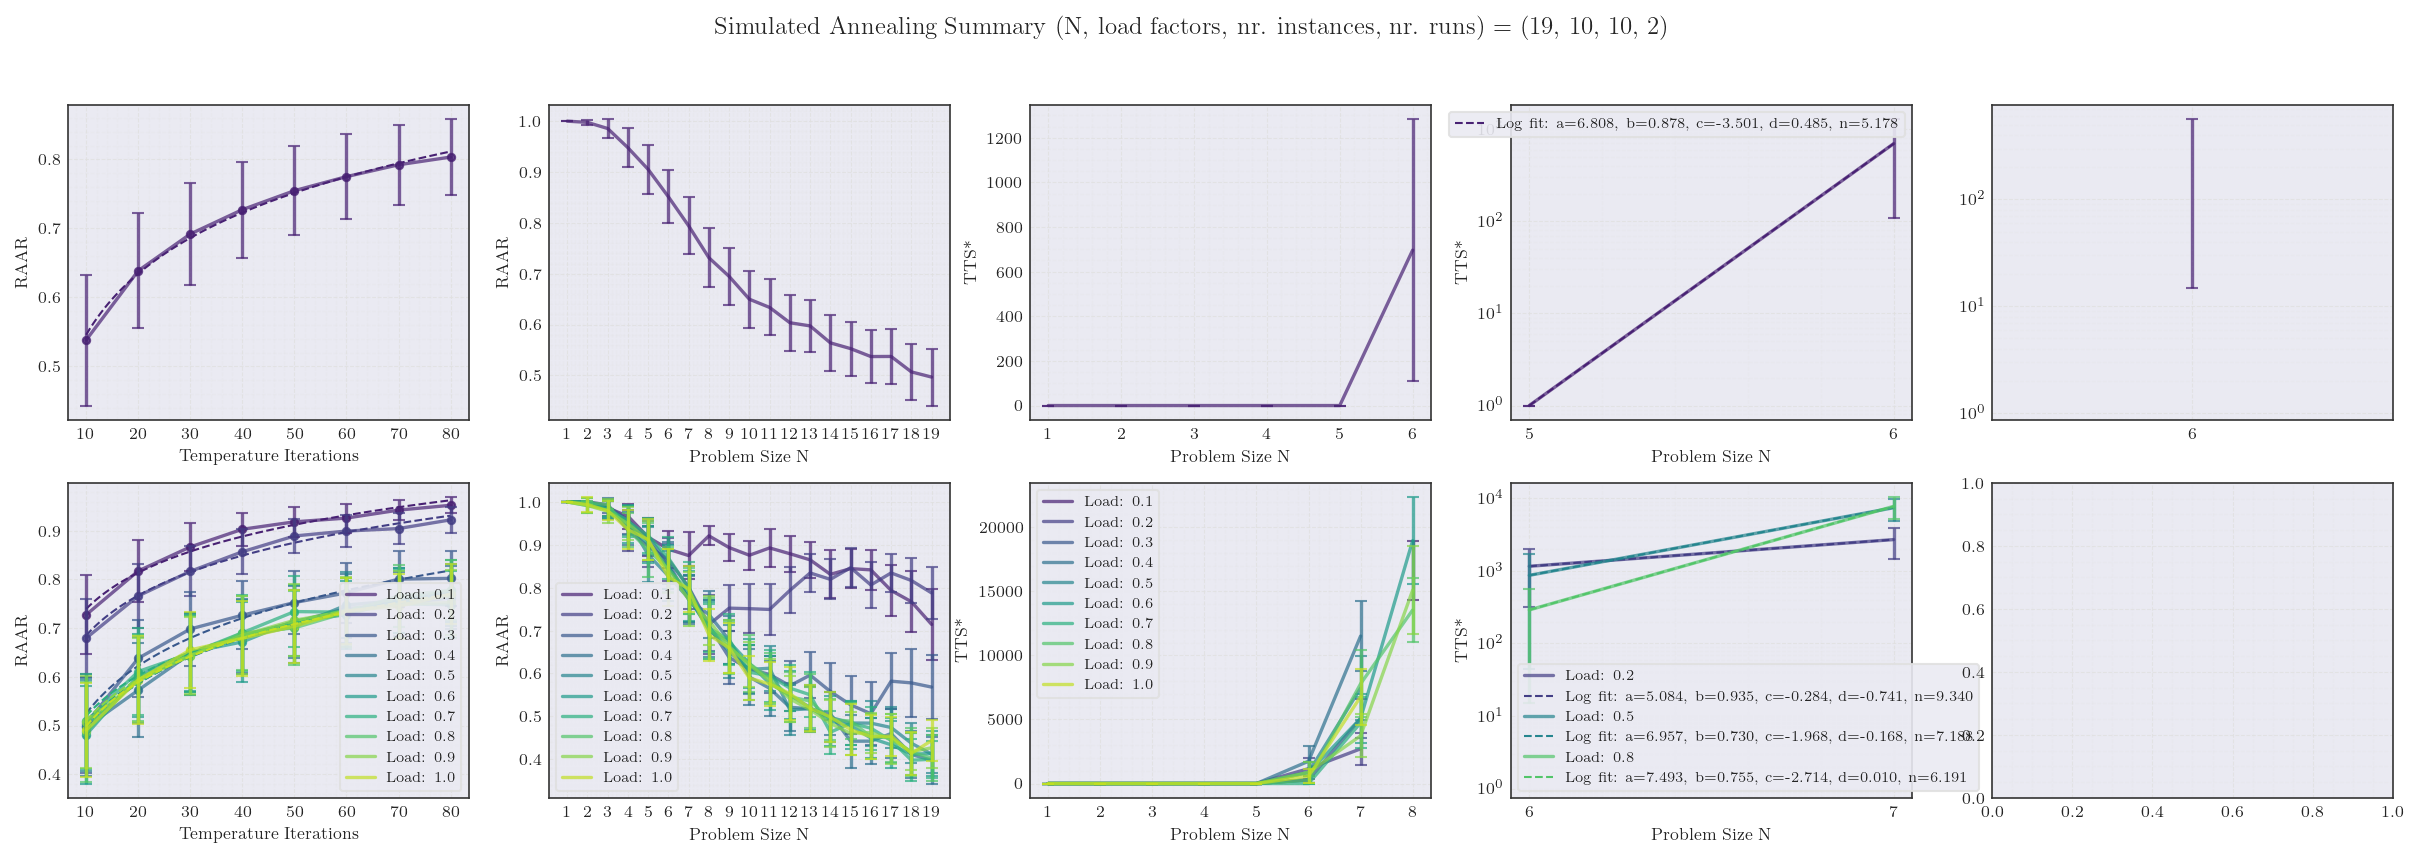

In [18]:
from plotting import plot_per_load_factor, plot_with_errorbar, log_plot_per_load_factor_with_fits, log_plot_with_fits
from datetime import datetime
import styling
import seaborn as sns

styling.set_my_style(use_latex=True)

palette = sns.color_palette("viridis", len(load_factors))


fig, ax = styling.subplots(2, 5, figsize=(20, 6))

fig.suptitle(f'Simulated Annealing Summary (N, load factors, nr. instances, nr. runs) = {loss_tensor.shape[0], loss_tensor.shape[1], loss_tensor.shape[2], loss_tensor.shape[3]}')

first_min_tts_greater_zero_index = np.where(avg_min_tts > 0)[0][0]
first_min_tts_greater_zero_index_per_load_factor = np.min(np.argmax(avg_min_tts_per_load_factor > 0, axis=0))

plot_with_errorbar(ax=ax[0, 0], xs=temp_iterations, means=mean_raars, stds=std_error_raars, labels=('RAAR', 'Temperature Iterations'), color=palette[0], regplot='log')
plot_with_errorbar(ax=ax[0, 1], xs=problem_sizes, means=mean_raars_per_problem_size, stds=std_error_raars_per_problem_size, labels=('RAAR', 'Problem Size N'), color=palette[0], set_xticks=True)
plot_with_errorbar(ax=ax[0, 2], xs=problem_sizes, means=avg_min_tts, stds=std_error_min_tts, labels=('TTS*', 'Problem Size N'), color=palette[0], set_xticks=True)
log_plot_with_fits(ax=ax[0, 3], xs=problem_sizes[first_min_tts_greater_zero_index:], means=avg_min_tts[first_min_tts_greater_zero_index:], stds=std_error_min_tts[first_min_tts_greater_zero_index:], labels=('TTS*', 'Problem Size N'), palette=palette, set_xticks=True)

plot_per_load_factor(
    ax=ax[1, 0],
    xs=temp_iterations,
    means=mean_raars_per_load_factor,
    stds=std_error_raars_per_load_factor,
    load_factors=load_factors,
    labels=("RAAR", 'Temperature Iterations'),
    palette=palette,
    regplot='log'
)
plot_per_load_factor(
    ax=ax[1, 1],
    xs=problem_sizes,
    means=mean_raars_per_problem_size_and_load_factor.T,
    stds=std_error_raars_per_problem_size_and_load_factor.T,
    load_factors=load_factors,
    labels=("RAAR", 'Problem Size N'),
    palette=palette,
    set_xticks=True,
)
plot_per_load_factor(
    ax=ax[1, 2],
    xs=problem_sizes,
    means=avg_min_tts_per_load_factor.T,
    stds=std_error_min_tts_per_load_factor.T,
    load_factors=load_factors,
    labels=("TTS*", 'Problem Size N'),
    palette=palette,
    set_xticks=True,
)
log_plot_per_load_factor_with_fits(
    ax=ax[1, 3],
    xs=problem_sizes[first_min_tts_greater_zero_index_per_load_factor:],
    means=avg_min_tts_per_load_factor.T[1::3, first_min_tts_greater_zero_index_per_load_factor:],
    stds=std_error_min_tts_per_load_factor.T[1::3, first_min_tts_greater_zero_index_per_load_factor:],
    load_factors=load_factors[1::3],
    labels=("TTS*", 'Problem Size N'),
    palette=palette[1::3],
    set_xticks=True,
)

indices = [0, 2, 6, 9]
print(load_factors[indices])
log_plot_per_load_factor_with_fits(
    ax=ax[0, 4],
    xs=problem_sizes[first_min_tts_greater_zero_index_per_load_factor:],
    means=avg_min_tts_per_load_factor.T[indices, first_min_tts_greater_zero_index_per_load_factor:],
    stds=std_error_min_tts_per_load_factor.T[indices, first_min_tts_greater_zero_index_per_load_factor:],
    load_factors=load_factors[indices],
    labels=("TTS*", 'Problem Size N'),
    palette=np.array(palette)[indices],
    set_xticks=True,
)
log_plot_per_load_factor_with_fits(
    ax=ax[1, 4],
    xs=problem_sizes[first_min_tts_greater_zero_index_per_load_factor:],
    means=avg_min_tts_per_load_factor.T[:, first_min_tts_greater_zero_index_per_load_factor:],
    stds=std_error_min_tts_per_load_factor.T[:, first_min_tts_greater_zero_index_per_load_factor:],
    load_factors=load_factors,
    labels=("TTS*", 'Problem Size N'),
    palette=palette,
    set_xticks=True,
)

plt.tight_layout()

dir_name = datetime.now().strftime("%Y%m%d-%H%M%S")
file_path = f'./plots/simulated_annealing/{dir_name}/summary.pdf'
save_dir = Path(f'./plots/simulated_annealing/{dir_name}')
save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(file_path)

In [24]:
print(f"Saved summary plot to: {file_path}")

NameError: name 'file_path' is not defined

In [25]:
subplot_names = ("RAAR_Temperature_Iterations_AVG", "RAAR_Problem_Size_AVG", "TTS_star_Problem_Size_AVG", "TTS_star_Problem_Size_AVG_LOG_FIT", "TTS_star_Problem_Size_Load_Factors_2_LOG_FIT", "RAAR_Temperature_Iterations_Load_Factors", "RAAR_Problem_Size_Load_Factors", "TTS_star_Problem_Size_Load_Factors", "TTS_star_Problem_Size_Load_Factors_1_LOG_FIT", "TTS_star_Problem_Size_Load_Factors_ALL_LOG_FIT")

for axis, name in zip(ax.flat, subplot_names):
    fig = axis.get_figure()
    extent = axis.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    filename = f"./plots/simulated_annealing/{dir_name}/{name}.pdf"
    fig.savefig(filename, bbox_inches=extent.expanded(1.05, 1.1))
    print(f"Saved to {filename}")

NameError: name 'dir_name' is not defined